# Solver benchmark analysis

Analysis of `ArbitraryExperiment_1.json`: each candidate solver is compared against the reference **ILP** solver.

Three views are produced for every candidate solver:
1. **Outcome breakdown** — matched / valid-suboptimal / invalid / error counts.
2. **Relative optimality gap heatmap** — mean gap (%) vs. ILP per (nodes × partitions), over cases that produced a solution.
3. **Success-rate heatmap** — share of cases that found a valid solution per (nodes × partitions).

Plots are saved to the `plots/` directory alongside this notebook.

In [ ]:
# --- Configuration -----------------------------------------------------------
# Edit INPUT_JSON to re-run this notebook against a different results file.
from pathlib import Path

CANDIDATE_ROOTS = [
    Path(r"/Users/danielarturi/Desktop/Quantum/QuantumClean"),
    Path.cwd(),
    Path.cwd().parent,
]
REPO_ROOT = next((p for p in CANDIDATE_ROOTS if (p / "result_bank").exists()), Path.cwd())

INPUT_JSON       = REPO_ROOT / "result_bank/simulated_solver_results_feasible/ArbitraryExperiment_1.json"
OUTPUT_DIR       = REPO_ROOT / "result_analysis"
PLOTS_DIR        = OUTPUT_DIR / "plots"
REFERENCE_SOLVER = "ILP"   # the optimal baseline every candidate is compared to

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
STEM = INPUT_JSON.stem  # used to namespace saved plot files
print("Input :", INPUT_JSON)
print("Plots :", PLOTS_DIR)

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

ModuleNotFoundError: No module named 'seaborn'

In [3]:
# --- Load and flatten --------------------------------------------------------
# The file is a dict with a "metadata" block and a "results" block. Each entry
# in "results" is one test case keyed by a descriptive string. We tolerate a
# file that is *just* the results mapping in case it was extracted separately.
raw = json.loads(INPUT_JSON.read_text())
results = raw["results"] if isinstance(raw, dict) and "results" in raw else raw
print(f"{len(results)} test cases loaded")
if isinstance(raw, dict) and "metadata" in raw:
    md = raw["metadata"]
    print("Metadata:", {k: md[k] for k in list(md)[:6]})

180 test cases loaded
Metadata: {'date': '2026-06-04', 'time': '19:50:02', 'total_cases': 180, 'num_reads': 200, 'solvers': ['ILP', 'SQA', 'SQA_SF'], 'harness_version': 'phase5'}


## Build the tidy results table

In [4]:
# --- Classification + gap logic ----------------------------------------------
# Categories for a candidate solver on a single test case:
#   "matched"          -> valid solution whose cost equals the ILP optimum
#   "valid_suboptimal" -> valid solution, but cost worse than the ILP optimum
#   "invalid"          -> a solution was produced but it violates a constraint
#   "error"            -> the case could not be completed (solver raised / no result)
CATEGORIES = ["matched", "valid_suboptimal", "invalid", "error"]
CATEGORY_LABELS = {
    "matched":          "Matched ILP cost",
    "valid_suboptimal": "Valid but suboptimal",
    "invalid":          "Invalid (constraint violation)",
    "error":            "Error (not completed)",
}

def classify(block, ilp_cost):
    """Assign one of CATEGORIES to a candidate solver's result block."""
    if not isinstance(block, dict):
        return "error"
    # An explicit error message, or no cost at all, means the case did not complete.
    if block.get("error") not in (None, "", False):
        return "error"
    if block.get("cost") is None:
        return "error"
    # A produced solution that violates constraints is invalid.
    if block.get("valid") is False:
        return "invalid"
    # From here the solution is valid; decide matched vs. suboptimal.
    cost = block.get("cost")
    if ilp_cost is not None and cost is not None and cost == ilp_cost:
        return "matched"
    gap_abs = block.get("optimality_gap_absolute")
    if gap_abs is not None:
        return "matched" if gap_abs == 0 else "valid_suboptimal"
    return "valid_suboptimal"

def relative_gap(block, ilp_cost):
    """Relative optimality gap as a fraction (0.05 == 5% worse than ILP).
    Prefers the precomputed field, then derives it from absolute gap or raw
    costs so older result schemas still work. Returns NaN when undefined."""
    if not isinstance(block, dict):
        return np.nan
    g = block.get("optimality_gap_relative")
    if g is not None:
        return float(g)
    ilp_cost = None if ilp_cost in (None, 0) else float(ilp_cost)
    if ilp_cost is None:
        return np.nan
    for key in ("optimality_gap_absolute", "optimality_gap"):
        v = block.get(key)
        if v is not None:
            return float(v) / ilp_cost
    cost = block.get("cost")
    if cost is not None:
        return (float(cost) - ilp_cost) / ilp_cost
    return np.nan

rows = []
for case_key, case in results.items():
    n_nodes = case.get("n_nodes")
    n_parts = case.get("n_partitions")
    solvers = case.get("solvers", {})
    ilp = solvers.get(REFERENCE_SOLVER, {})
    ilp_cost = ilp.get("cost") if isinstance(ilp, dict) else None
    for sname, block in solvers.items():
        if sname == REFERENCE_SOLVER:
            continue
        category = classify(block, ilp_cost)
        rows.append({
            "case": case_key,
            "solver": sname,
            "n_nodes": n_nodes,
            "n_partitions": n_parts,
            "ilp_cost": ilp_cost,
            "cost": block.get("cost") if isinstance(block, dict) else None,
            "valid": bool(block.get("valid")) if isinstance(block, dict) else False,
            "category": category,
            "gap_rel": relative_gap(block, ilp_cost),
        })

df = pd.DataFrame(rows)
df["category"] = pd.Categorical(df["category"], categories=CATEGORIES, ordered=True)
SOLVERS = sorted(df["solver"].unique())
print("Candidate solvers:", SOLVERS)
df.head()

Candidate solvers: ['SQA', 'SQA_SF']


,case,solver,n_nodes,n_partitions,ilp_cost,cost,valid,category,gap_rel
0,n-3_p-12_1__t30,SQA,3,12,204,317,True,valid_suboptimal,0.5539
1,n-3_p-12_1__t30,SQA_SF,3,12,204,341,True,valid_suboptimal,0.6716
2,n-3_p-12_2__t30,SQA,3,12,217,271,True,valid_suboptimal,0.2488
3,n-3_p-12_2__t30,SQA_SF,3,12,217,295,True,valid_suboptimal,0.3594
4,n-3_p-12_3__t30,SQA,3,12,47,128,True,valid_suboptimal,1.7234


## 1. Outcome breakdown by solver

In [5]:
# --- Analysis 1: classification breakdown ------------------------------------
# Count, per candidate solver, how many cases fall into each category.
breakdown = (
    df.groupby(["solver", "category"], observed=False)
      .size()
      .unstack("category")
      .reindex(columns=CATEGORIES)
      .fillna(0)
      .astype(int)
)
breakdown["total"] = breakdown.sum(axis=1)
breakdown_display = breakdown.rename(columns=CATEGORY_LABELS)
breakdown_display

category,Matched ILP cost,Valid but suboptimal,Invalid (constraint violation),Error (not completed),total
solver,,,,,
SQA,17,157,6,0,180
SQA_SF,12,145,23,0,180


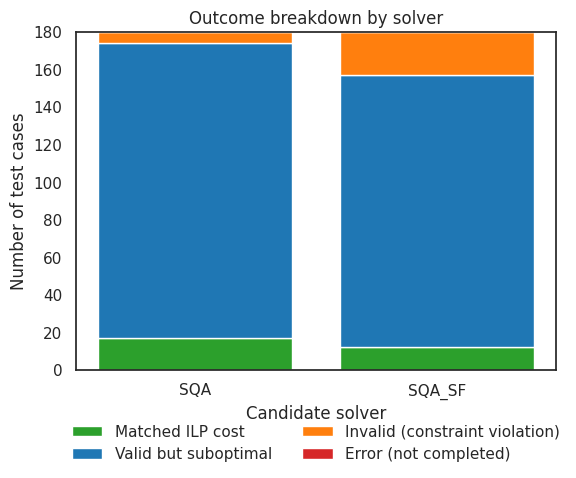

In [6]:
# Stacked bar chart of the breakdown, one bar per candidate solver.
colors = {
    "matched":          "#2ca02c",
    "valid_suboptimal": "#1f77b4",
    "invalid":          "#ff7f0e",
    "error":            "#d62728",
}
fig, ax = plt.subplots(figsize=(max(6, 1.6 * len(SOLVERS)), 5))
bottom = np.zeros(len(breakdown))
for cat in CATEGORIES:
    vals = breakdown[cat].values
    ax.bar(breakdown.index, vals, bottom=bottom, label=CATEGORY_LABELS[cat], color=colors[cat])
    bottom += vals
ax.set_ylabel("Number of test cases")
ax.set_xlabel("Candidate solver")
ax.set_title("Outcome breakdown by solver")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"{STEM}__classification_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Average relative optimality gap (%)

In [7]:
# --- Heatmap helpers ---------------------------------------------------------
def heatmap_grid(pivot, title, cbar_label, fname, fmt=".1f", cmap="viridis", vmin=None, vmax=None):
    """Render one (n_nodes x n_partitions) heatmap. Rows = nodes, cols = partitions."""
    if pivot.empty:
        print(f"  (no data for: {title})")
        return
    fig, ax = plt.subplots(figsize=(max(5, 0.7 * pivot.shape[1] + 2),
                                    max(4, 0.6 * pivot.shape[0] + 2)))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": cbar_label}, ax=ax)
    ax.set_xlabel("Number of partitions")
    ax.set_ylabel("Number of nodes")
    # ax.set_title(title)  # header removed: redundant with figure/subfigure caption (Scherzinger review)
    ax.invert_yaxis()  # smaller node counts at the bottom
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

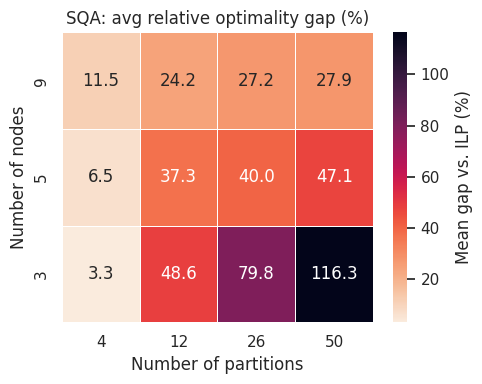

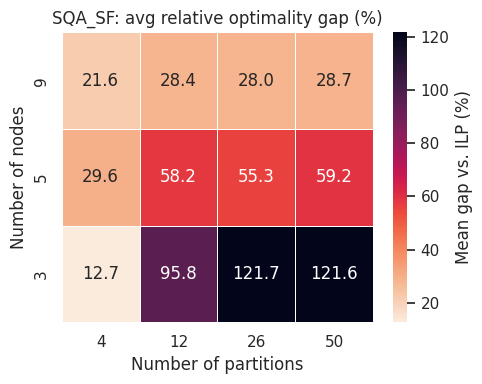

In [8]:
# --- Analysis 2: average relative optimality gap (%) -------------------------
# Only valid solutions are included: an invalid assignment violates a constraint,
# so its cost (and therefore its gap vs. ILP) is not a meaningful comparison.
# Error cases are naturally excluded too. To instead include invalid solutions
# (gap over every case that produced any assignment), change the filter to:
#   solved = df[df["category"] != "error"].copy()
solved = df[df["category"].isin(["matched", "valid_suboptimal"])].copy()
solved["gap_pct"] = solved["gap_rel"] * 100.0

for solver in SOLVERS:
    sub = solved[(solver == solved["solver"]) & solved["gap_pct"].notna()]
    pivot = sub.pivot_table(index="n_nodes", columns="n_partitions",
                            values="gap_pct", aggfunc="mean")
    heatmap_grid(
        pivot,
        title=f"{solver}: avg relative optimality gap (%)",
        cbar_label="Mean gap vs. ILP (%)",
        fname=f"{STEM}__{solver}__optgap_relative_heatmap.png",
        cmap="rocket_r",
        vmin=0, vmax=160,   # shared optimality-gap color scale (Global 0-160)
    )

## 3. Valid-solution success rate (%)

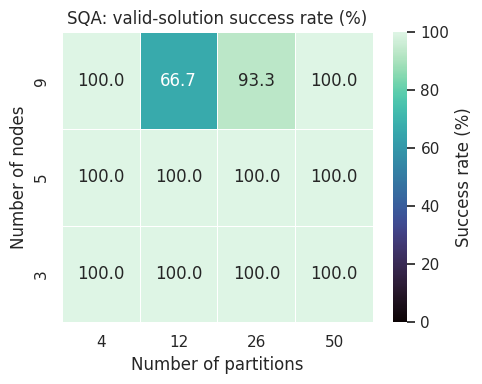

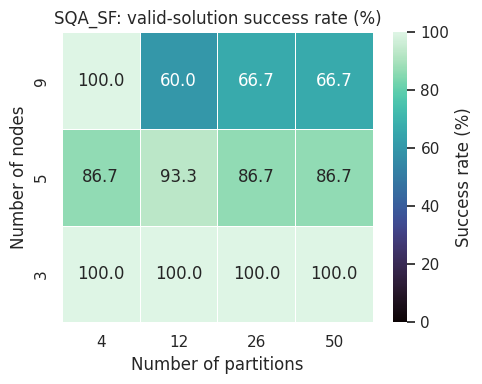

In [9]:
# --- Analysis 3: success rate of finding a valid solution (%) ----------------
# Denominator is every case attempted at that configuration (error and invalid
# cases both count as failures); numerator is cases with a valid solution.
df["found_valid"] = df["category"].isin(["matched", "valid_suboptimal"])

for solver in SOLVERS:
    sub = df[solver == df["solver"]]
    pivot = sub.pivot_table(index="n_nodes", columns="n_partitions",
                            values="found_valid", aggfunc="mean") * 100.0
    heatmap_grid(
        pivot,
        title=f"{solver}: valid-solution success rate (%)",
        cbar_label="Success rate (%)",
        fname=f"{STEM}__{solver}__success_rate_heatmap.png",
        cmap="mako",
        vmin=0, vmax=100,
    )

## Summary

In [10]:
# --- Text summary ------------------------------------------------------------
for solver in SOLVERS:
    sub = df[solver == df["solver"]]
    total = len(sub)
    matched = (sub["category"] == "matched").sum()
    valid = sub["found_valid"].sum()
    print(f"{solver}: {total} cases | "
          f"matched ILP {matched} ({matched/total:.0%}) | "
          f"valid {valid} ({valid/total:.0%}) | "
          f"errors {(sub['category']=='error').sum()}")

SQA: 180 cases | matched ILP 17 (9%) | valid 174 (97%) | errors 0
SQA_SF: 180 cases | matched ILP 12 (7%) | valid 157 (87%) | errors 0
